# Hotel revenue Forecasting Pipeline 

This notebook demonstrates the complete pipeline for forecasting hotel revenue values using various time series models, targeting multiple forecast horizons

# Forecasting pipeline

1.  **Exploratory analysis**:
    1.  Univariate statistical analysis (applied to averages or specific examples)
    2.  Descriptive statistics for multivariate TS
    3.  Correlation between TS
    4.  etc..
2.  **Univariate benchmark models**. Chose one or more benchmark methods we have seen in the course and retrieve a baseline in terms of performance
    1.  naive methods
    2.  Holt-Winters, AR(I)MAX
3.  **Model proposal and training**
    1.  cross validation (time or purged k-fold) and hyperpar optimization (potentially per target or averaged)
    2.  point and *probabilistic* forecasts
    3.  choice of the score metrics
4.  **Model selection**
    1.  Selection (potentially per target or overall best)
    2.  Reporting results



## 1. Data Loading and Initial Exploration

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime, timedelta

# Time series libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Scikit-learn for additional models
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Set style and suppress warnings
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
with open('hotels.pk', 'rb') as f:
    data = pickle.load(f)

# Convert to DataFrame if needed
if not isinstance(data, pd.DataFrame):
    df = pd.DataFrame(data)
else:
    df = data.copy()

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully!
Dataset shape: (23254, 4)

Column names:
['Location', 'Revenue', 'Demand', 'Occupancy']


In [3]:
print(df.index.dtype)

datetime64[ns]


In [4]:
df.head()

,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,NewYork,2.442363e+06,13063.675000,81.991307
2013-01-02,NewYork,2.018559e+06,13069.608539,82.028548
2013-01-03,NewYork,1.927676e+06,13069.608539,82.028548
2013-01-04,NewYork,1.781664e+06,12653.271887,79.415502
2013-01-05,NewYork,1.824994e+06,12827.322364,80.507892


In [5]:
# Examine the data structure and basic info
print("Data Info:")
print(df.info())
print("\n" + "="*50)
print("Index (Date) Info:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Number of days: {len(df.index.unique())}")
print("\n" + "="*50)
print("Unique locations:")
locations = df['Location'].unique()
print(locations)
print(f"Number of locations: {len(locations)}")
print("\n" + "="*50)
print("Data per location:")
print(df['Location'].value_counts().sort_values(ascending=False))

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23254 entries, 2013-01-01 to 2020-10-31
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   23254 non-null  object 
 1   Revenue    23254 non-null  float64
 2   Demand     23254 non-null  float64
 3   Occupancy  23254 non-null  float64
dtypes: float64(3), object(1)
memory usage: 908.4+ KB
None

Index (Date) Info:
Date range: 2012-01-01 00:00:00 to 2020-10-31 00:00:00
Number of days: 3227

Unique locations:
['NewYork' 'Orlando' 'Chicago' 'LosAngeles' 'Washington' 'Atlanta'
 'Dallas' 'Boston']
Number of locations: 8

Data per location:
Location
Atlanta       3227
NewYork       2861
Chicago       2861
Orlando       2861
LosAngeles    2861
Washington    2861
Dallas        2861
Boston        2861
Name: count, dtype: int64


## 2. Data Preprocessing


In [6]:
# Basic statistics for each location
print("Revenue Statistics by Location:")
print("="*80)
revenue_stats = df.groupby('Location')['Revenue'].agg(['count', 'mean', 'std', 'min', 'max'])
revenue_stats['mean'] = revenue_stats['mean'].round(0)
revenue_stats['std'] = revenue_stats['std'].round(0)
print(revenue_stats)

print("\n\nMissing values check:")
print(df.isnull().sum())

print("\n\nData types:")
print(df.dtypes)

Revenue Statistics by Location:
            count       mean        std            min           max
Location                                                            
Atlanta      3227  1168859.0   407251.0  300130.994748  3.527372e+06
Boston       2861   815105.0   376528.0  114523.553351  2.035877e+06
Chicago      2861  1275021.0   532755.0  191560.618017  3.194662e+06
Dallas       2861   953418.0   313810.0  246828.548026  2.042266e+06
LosAngeles   2861  1047586.0   307256.0  164409.176800  1.839768e+06
NewYork      2861  3152937.0  1208497.0  588695.817812  7.940696e+06
Orlando      2861  1860535.0   691470.0   88994.827420  4.346277e+06
Washington   2861  1527573.0   597672.0  275723.044727  3.974323e+06


Missing values check:
Location     0
Revenue      0
Demand       0
Occupancy    0
dtype: int64


Data types:
Location      object
Revenue      float64
Demand       float64
Occupancy    float64
dtype: object


## 3. Exploratory Data Analysis and Visualization

provare a visualizzare con ipywidget (grafici potrebbero essere migliori)
stessa cosa nella matrice delle correlazioni, correlazione tra features molto forte -> esplorare correlazione solo tra features per evitare collinearitâ (si potrebbe combinare le features o tenerne solo una delle due)

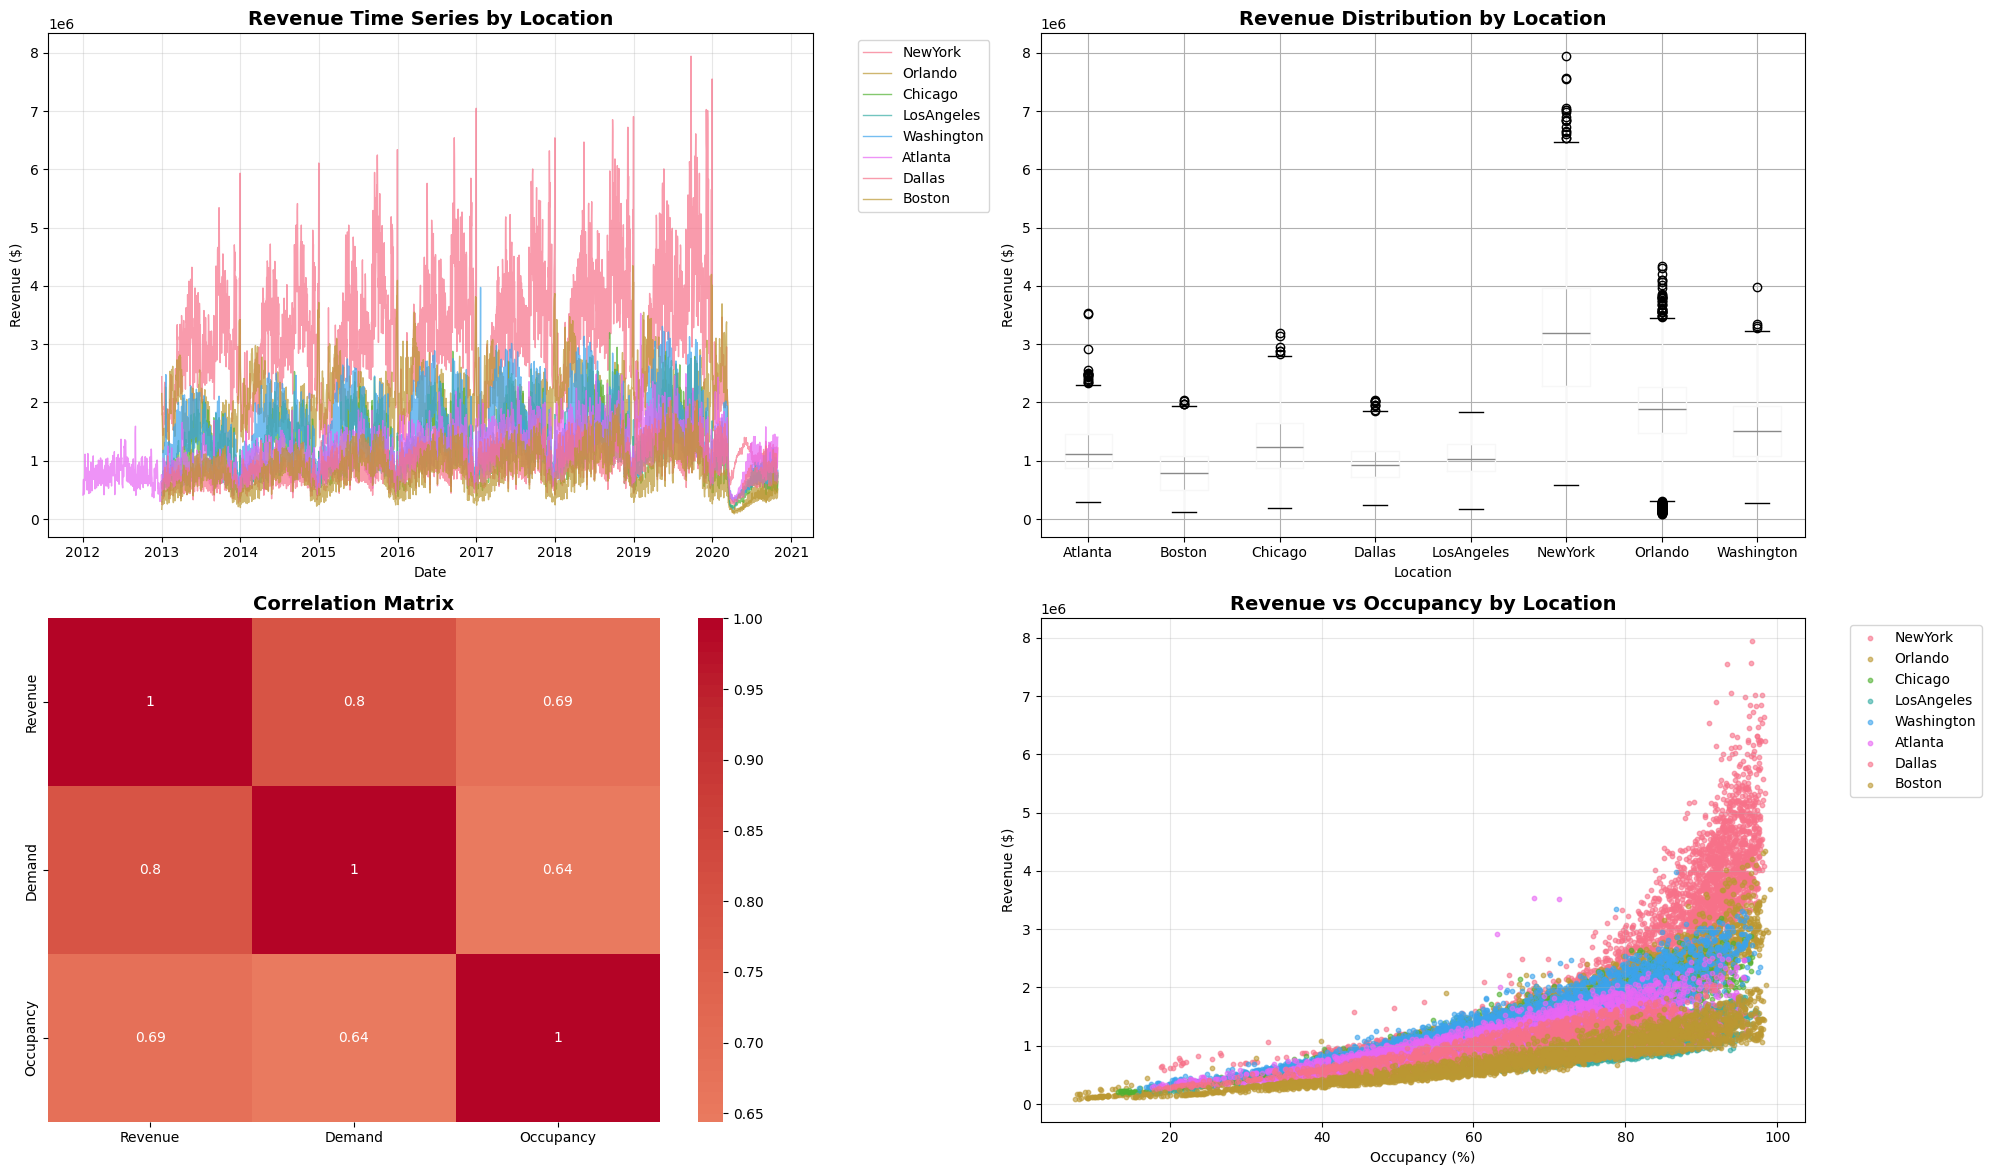

In [7]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1. Revenue time series by location
ax1 = axes[0, 0]
for location in df['Location'].unique():
    location_data = df[df['Location'] == location]
    ax1.plot(location_data.index, location_data['Revenue'], 
             label=location, alpha=0.7, linewidth=1)
ax1.set_title('Revenue Time Series by Location', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue ($)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Average revenue by location (box plot)
ax2 = axes[0, 1]
df.boxplot(column='Revenue', by='Location', ax=ax2)
ax2.set_title('Revenue Distribution by Location', fontsize=14, fontweight='bold')
ax2.set_xlabel('Location')
ax2.set_ylabel('Revenue ($)')
plt.suptitle('')  # Remove automatic title

# 3. Correlation matrix
ax3 = axes[1, 0]
# Select numeric columns for correlation
numeric_cols = ['Revenue', 'Demand', 'Occupancy']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax3)
ax3.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

# 4. Revenue vs Occupancy scatter plot
ax4 = axes[1, 1]
for location in df['Location'].unique():
    location_data = df[df['Location'] == location]
    ax4.scatter(location_data['Occupancy'], location_data['Revenue'], 
                label=location, alpha=0.6, s=10)
ax4.set_title('Revenue vs Occupancy by Location', fontsize=14, fontweight='bold')
ax4.set_xlabel('Occupancy (%)')
ax4.set_ylabel('Revenue ($)')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

we can see an important correlation between Demand, Occupancy and our target Revenue. We want to check if there is collinearity between features to avoid overfitting in the model

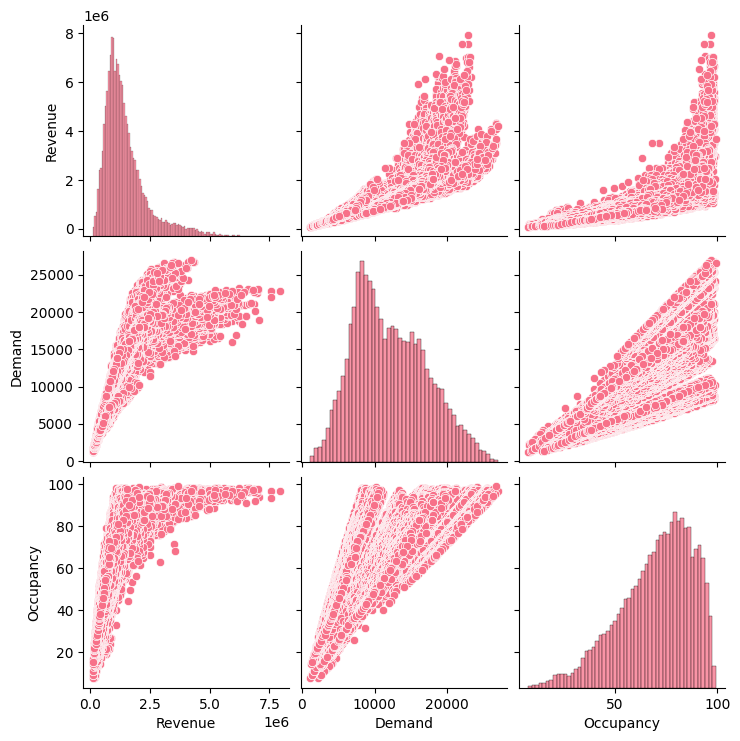

In [8]:
sns.pairplot(df[['Revenue', 'Demand', 'Occupancy']])
plt.show()

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Esempio: solo alcune feature
X = df[['Revenue', 'Demand', 'Occupancy']].dropna()

# Aggiungi una costante per il calcolo del VIF
from statsmodels.tools.tools import add_constant
X_const = add_constant(X)

vif = pd.DataFrame()
vif["feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif


,feature,VIF
0,const,20.075335
1,Revenue,3.173136
2,Demand,2.865540
3,Occupancy,1.990786


## 4. City Selection and Focus

Based on the analysis, let's select **Boston** as our focus city for forecasting due to:
1. Highest revenue levels among all cities
2. Strong seasonal patterns visible in the time series
3. Good data quality and range

In [10]:
# Filter for one city
CITY = "Boston"
df_boston = df[df['Location'] == CITY].copy()

# Use index (already DateTimeIndex)
df_boston.index = pd.to_datetime(df_boston.index)

# Restrict date range
df_boston
df_boston.head()


,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,Boston,166542.843005,1896.791481,22.856617
2013-01-02,Boston,245252.313124,2744.958462,33.077154
2013-01-03,Boston,289687.425946,3172.063926,38.223838
2013-01-04,Boston,297390.047491,3308.052694,39.862523
2013-01-05,Boston,291848.455941,3235.525351,38.988557


In [ ]:
print(df_boston.index.min(), "→", df_boston.index.max())

#verify that the intervals are regualr (daily) 

print(df_boston.index.to_series().diff().value_counts())

2013-01-01 00:00:00 → 2020-10-31 00:00:00
Date
1 days    2860
Name: count, dtype: int64


In [12]:
from ipywidgets import interact, interactive, IntSlider, DatePicker

start_picker = DatePicker(
    description='Start date',
    value=df.index.min().date(),
    disabled=False
)
end_picker = DatePicker(
    description='End date',
    value=df.index.max().date(),
    disabled=False
)

@interact(start=start_picker, end=end_picker)
def plot_time_series(start, end):
    mask = (df_boston.index >= pd.to_datetime(start)) & (df_boston.index <= pd.to_datetime(end))
    plt.figure(figsize=(10, 4))
    plt.plot(df_boston.loc[mask].index, df_boston.loc[mask]['Revenue'], color='teal')
    plt.title(f"Hotel Revenue ({start} → {end})")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.grid(True, alpha=0.3)
    plt.show()


interactive(children=(DatePicker(value=datetime.date(2012, 1, 1), description='Start date', step=1), DatePicke…

because the line plot is a bit chaotic, let's analyse the timeserie in  a macro view

In [ ]:
@interact(start=start_picker, end=end_picker)
def plot_rolling(start, end):
    mask = (df_boston.index >= pd.to_datetime(start)) & (df_boston.index <= pd.to_datetime(end))
    subset = df_boston.loc[mask]

    plt.figure(figsize=(12,6))
    plt.plot(subset['Revenue'].rolling(7, center=True).mean(), 
             label='Rolling 7-day', alpha=0.8, color='teal')
    plt.plot(subset['Revenue'].rolling(30, center=True).mean(), 
             label='Rolling 30-day (≈ monthly)', alpha=0.8, color='orange')
    plt.plot(subset['Revenue'].rolling(365, center=True).mean(), 
             label='Rolling 365-day (yearly)', alpha=0.9, color='crimson')

    plt.title(f'Hotel Revenue – Rolling Averages ({start} → {end})')
    plt.xlabel('Date')
    plt.ylabel('Revenue (smoothed)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(DatePicker(value=datetime.date(2012, 1, 1), description='Start date', step=1), DatePicke…

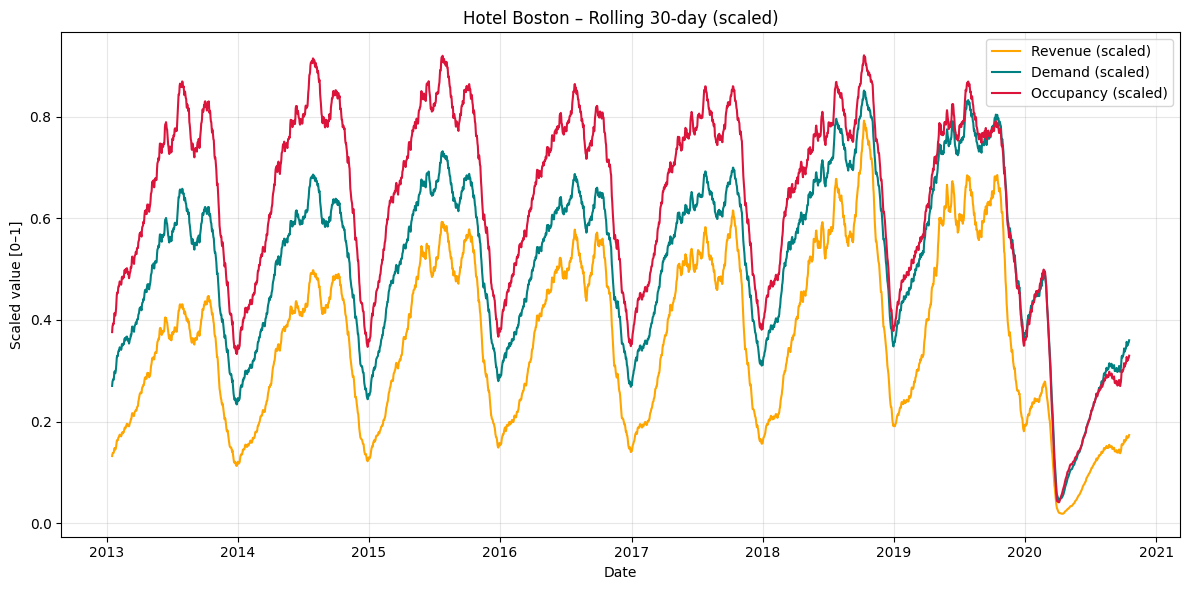

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_boston[['Revenue', 'Demand', 'Occupancy']])
scaled_df = pd.DataFrame(scaled, index=df_boston.index, columns=['Revenue', 'Demand', 'Occupancy'])

plt.figure(figsize=(12,6))
plt.plot(scaled_df['Revenue'].rolling(30, center=True).mean(), label='Revenue (scaled)', color='orange')
plt.plot(scaled_df['Demand'].rolling(30, center=True).mean(), label='Demand (scaled)', color='teal')
plt.plot(scaled_df['Occupancy'].rolling(30, center=True).mean(), label='Occupancy (scaled)', color='crimson')

plt.title('Hotel Boston – Rolling 30-day (scaled)')
plt.xlabel('Date')
plt.ylabel('Scaled value [0–1]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [30]:
@interact(metric=['Revenue', 'Demand', 'Occupancy'])
def plot_seasonal(metric):
    df_boston['Month'] = df_boston.index.month_name().str.slice(stop=3)
    df_boston['Year'] = df_boston.index.year
    monthly = df_boston.groupby(['Year', 'Month'])[metric].mean().reset_index()
    
    # Ordine corretto dei mesi
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly['Month'] = pd.Categorical(monthly['Month'], categories=month_order, ordered=True)
    
    plt.figure(figsize=(12,6))
    sns.lineplot(data=monthly, x='Month', y=metric, hue='Year', palette='coolwarm')
    plt.title(f'Seasonal Plot – Monthly {metric} by Year')
    plt.xlabel('Month')
    plt.ylabel(metric)
    plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='metric', options=('Revenue', 'Demand', 'Occupancy'), value='Revenu…

Usually the revenues, 

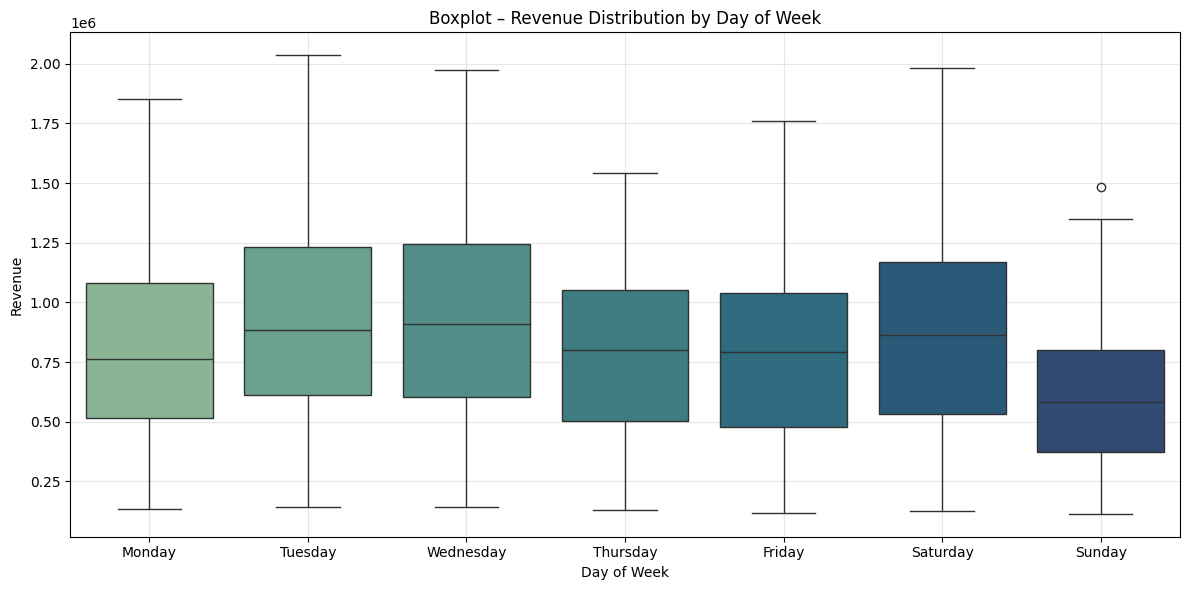

In [36]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_boston, x='DayOfWeek', y='Revenue', palette='crest')
plt.title('Boxplot – Revenue Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

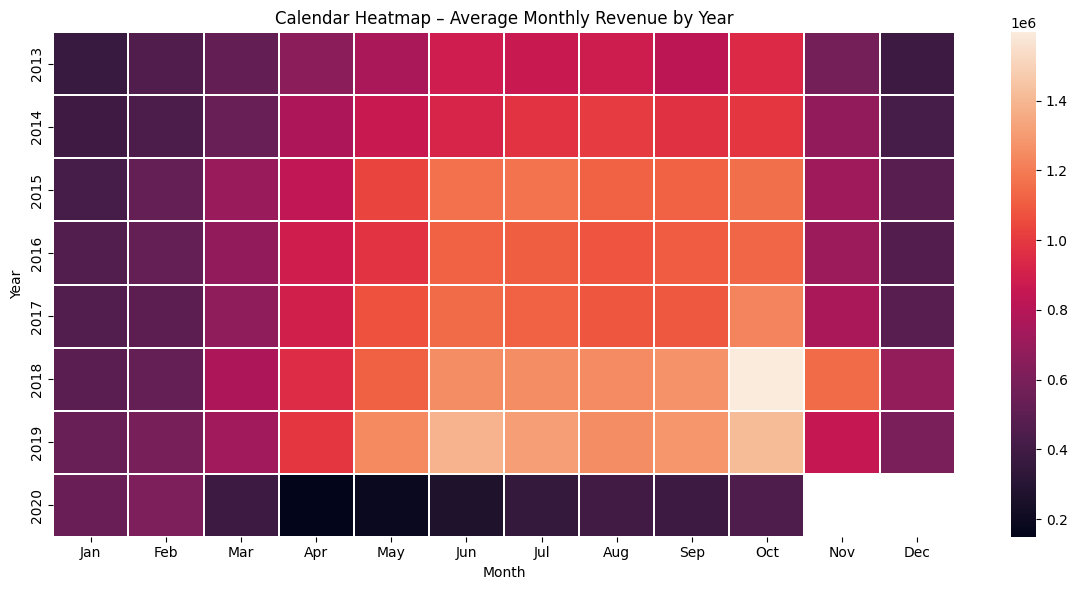

In [46]:
pivot2 = df_boston.pivot_table(values='Revenue',
                               index='Year',
                               columns='Month',
                               aggfunc='mean')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot2 = pivot2[month_order]

plt.figure(figsize=(12,6))
sns.heatmap(pivot2, linewidths=0.3, annot=False)
plt.title('Calendar Heatmap – Average Monthly Revenue by Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

## 5. Decomposition

because we don't have missing values and we have high-frequency data (daily) that can exhibit multiple seasonal patterns we can use an extension of STL decomposition for mulitple seasonality known as **MSTL** using LOESS

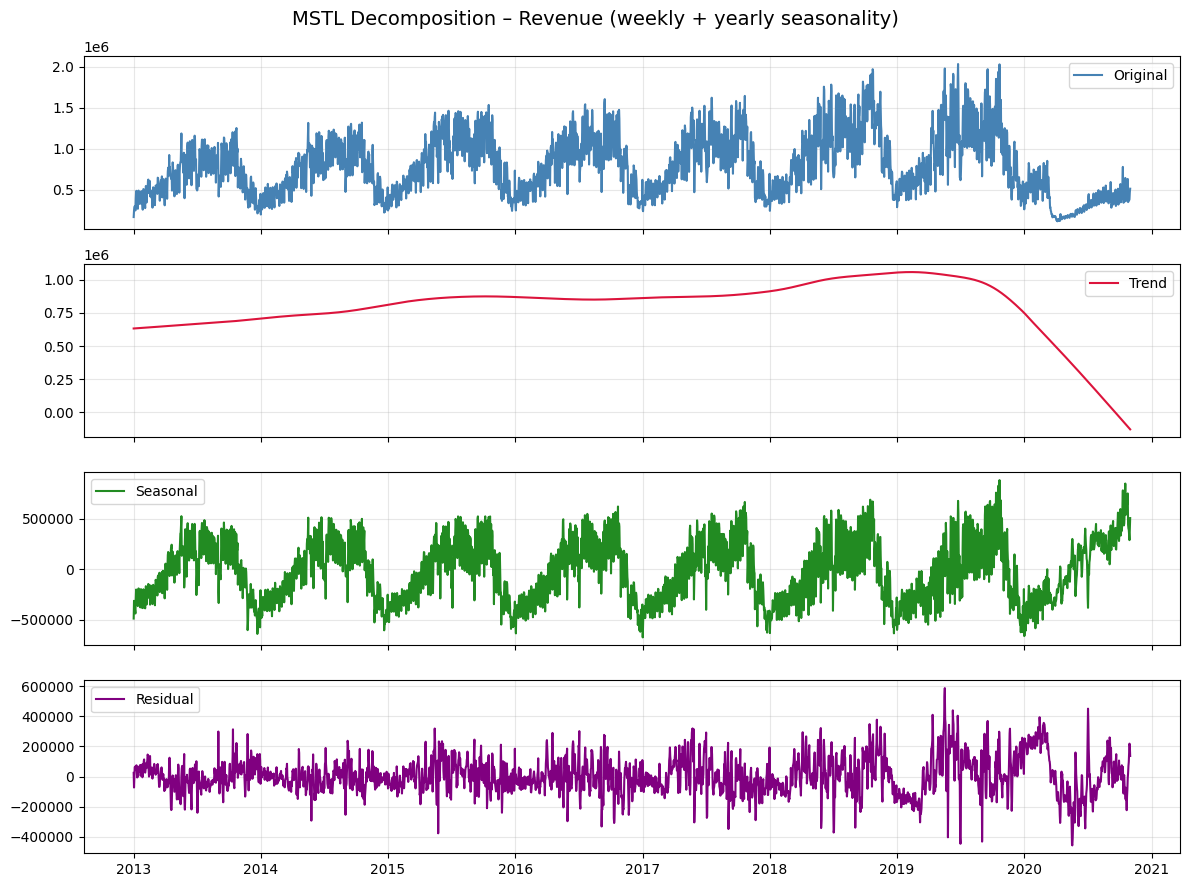

In [ ]:
from statsmodels.tsa.seasonal import MSTL
y = df_boston['Revenue'].asfreq('D')
mstl = MSTL(y, periods=(7, 365))
res = mstl.fit()

trend = res.trend
seasonal = res.seasonal.sum(axis=1)  
resid = res.resid

fig, axs = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axs[0].plot(y, color='steelblue', label='Original')
axs[1].plot(trend, color='crimson', label='Trend')
axs[2].plot(seasonal, color='forestgreen', label='Seasonal')
axs[3].plot(resid, color='purple', label='Residual')

for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('MSTL Decomposition – Revenue (weekly + yearly seasonality)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Stationarity Check

## 7. Autocorrelation Analysis

## 8. Outlier Detection